# 0.2 · Preliminary four-channel CO₂ spectra

**Dimitri Bolt — LEO West (x=1, y=4)**

**PRELIMINARY — QC AND TIME BASE UNRESOLVED**

This demonstration asks which amplitude features are visible in the longest available common calendar envelope after the existing technical masks. It does **not** establish scientific admission, final frequencies, relative phases, or the transition to stage 0.3 / main chapter 1.

[Research plan](PLAN.md) · [Preparation and unresolved questions](details/02_data_checks.md#preliminary-four-channel-spectra) · [Shared implementation](../sensorDB/preliminary_spectra.py)

## Experimental dataset

The completed, independently downloaded archive `20261002T061358Z-264980` contains **53 channels; 41,946,851 original measurements; 16 subsurface vertical profiles; 2 candidates after technical filters**. These totals are checked against the archive's hashed diagnostic tables on every run.

For this demonstration: **996 / 1012 / 1035; 5 / 20 / 50 cm; LI-COR 1275, horizontal offset 1 m**. Basalt coordinates are (1,4,−0.05/−0.20/−0.50) m; air coordinates in Excel are (0,4,0.25) m. Air Oracle BOXZ=0.05 m disagrees with Excel Z=0.25 m; no reconciliation is assumed. Source units remain `ppm` (basalt) and `umol/mol` (air).

The candidate calendar is [29 April 2025, 2 October 2026), including 1 October. **520 calendar days with four-channel observations after technical masks, including unresolved quality flags**, do not mean continuous or fully validated data. There are two common occupied-day runs: 29 April–11 August 2025 and 13 August 2025–1 October 2026. The entire missing air day is 12 August. Occupied days and 2-hour bins describe calendar coverage, not simultaneous samples.

The source `LOCALDATETIME` clock / time zone is unconfirmed. No time-zone conversion or resynchronization is applied. All retained air values have unresolved numerical QC, and retained subsurface doubts remain visible.

In [1]:
from pathlib import Path
import sys, io, json
import numpy as np
import pandas as pd
from IPython.display import display, Image as DisplayImage
from PIL import Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Project_description/sensorDB/preliminary_spectra.py').exists())
sys.path.insert(0, str(ROOT / 'Project_description/sensorDB'))
import preliminary_spectra as ps
series, spectra, passport, work, raw = ps.prepare()
display(pd.DataFrame(passport['channels'])[['sensorid','sensorcode','units','raw_rows','retained_rows','doubtful_rows','excluded_times','median_step_s','max_gap_h','static_n']])

,sensorid,sensorcode,units,raw_rows,retained_rows,doubtful_rows,excluded_times,median_step_s,max_gap_h,static_n
0,1275,LEO-W_4_0_1_LI-7000,umol/mol,7589,7589,7589,0,7200.0,43.334167,7577
1,996,LEO-W_4_1_1_GMM222,ppm,50009,49784,188,225,900.0,1.250278,49742
2,1012,LEO-W_4_1_2_GMM222,ppm,50009,49770,193,239,900.0,1.250278,49728
3,1035,LEO-W_4_1_4_GMM222,ppm,50009,49715,206,294,900.0,1.250278,49715


## Coverage and the common envelope

All spectra use the same bounds: **2025-04-29 10:30:01 to 2026-10-01 23:00:01**, the intersection of the four retained timestamp envelopes. This is the longest envelope, **not** a claim of continuous overlap. Each channel keeps its own actual timestamps and internal gaps; excluded observations are absent, never replaced with zero. The broader requested calendar contains 7,589 / 49,784 / 49,770 / 49,715 retained observations (air / 5 / 20 / 50 cm). The stricter common envelope uses 7,577 / 49,742 / 49,728 / 49,715.

The table below shows monthly occupied days and retained counts. Full raw/retained/excluded/review counts and 2-hour occupancy are saved in [monthly coverage](output/preliminary_spectra/monthly_coverage.csv). [Gap list](output/preliminary_spectra/gaps.csv) follows the archive's descriptive gap definition (>1.5×median positive step), without imposing a new exclusion. Maximum internal gaps are 43.334 h (air) and 1.2503 h (each basalt channel). Missing edges are separately shown in the sliding-window explorer.

In [2]:
monthly = pd.read_csv(ps.OUT / 'monthly_coverage.csv')
display(monthly.pivot(index='month', columns='sensorid', values=['occupied_days','retained_rows']))
print('Common occupied-day runs:', passport['common_daily_runs'])
print('Common span:', round(passport['span_days'], 6), 'days; frequency step:', passport['frequency_step'], 'cycles/day')

occupied_days                retained_rows                 
sensorid          996  1012 1035 1275          996   1012  1035 1275
month                                                               
2025-04              2    2    2    2           192   192   149   49
2025-05             31   31   31   31          2963  2967  2966  752
2025-06             30   30   30   30          2866  2862  2865  723
2025-07             31   31   31   31          2966  2954  2960  664
2025-08             31   31   31   30          2964  2962  2960  492
2025-09             30   30   30   30          2871  2871  2867  506
2025-10             31   31   31   31          2960  2968  2962  397
2025-11             30   30   30   30          2868  2870  2866  347
2025-12             31   31   31   31          2960  2963  2958  372
2026-01             31   31   31   31          2960  2961  2964  372
2026-02             28   28   28   28          2675  2676  2670  336
2026-03             31   31   31   31          2962  2961  2954  372
2026-04             30   30   30   30          2864  2866  2868  360
2026-05             31   31   31   31          2965  2962  2953  370
2026-06             30   30   30   30          2866  2857  2870  361
2026-07             31   31   31   31          2962  2962  2960  372
2026-08             31   31   31   31          2963  2959  2961  372
2026-09             30   30   30   30          2864  2865  2869  360
2026-10              1    1    1    1            93    92    93   12

Common occupied-day runs: [{'start': '2025-04-29', 'end_exclusive': '2025-08-12', 'days': 105}, {'start': '2025-08-13', 'end_exclusive': '2026-10-02', 'days': 415}]
Common span: 520.520833 days; frequency step: 0.0019211526916149688 cycles/day


## Method: floating-mean generalized Lomb–Scargle

At every trial frequency, minimize the equal-weight squared residual on actual timestamps:

$$C(t_i)=c+a\cos(2\pi f t_i)+b\sin(2\pi f t_i),\qquad A(f)=\sqrt{a^2+b^2}.$$

**A is the sinusoidal semi-amplitude in the channel's source units**, not power, peak-to-peak amplitude, or variance normalization. The floating constant is independently fitted at each frequency; subtracting an arithmetic mean first is used only as an algebraic elimination step. No trend removal, taper, interpolation, resampling or phase calculation is performed. Measurement uncertainties are unavailable, so weights are equal. No frequency significance or noise model is asserted.

The common envelope T=520.520833 days sets Δf=1/T≈0.001921153 cycles/day, with f=k/T and **0<f<6 cycles/day**. The upper display limit reflects the slow modal air cadence of 2 h. It is not a strict Nyquist theorem for irregular sampling. Exactly 6/day is excluded because near-regular 2-hour segments cannot stably determine both sinusoidal coefficients there; tiny timestamp jitter otherwise yields very large unstable amplitudes. A finer interpolated grid is not introduced. Frequencies off this grid can have a lower sampled maximum; a narrow peak's location is not a precision estimate.

The daily frequency is a reference, not a selected answer. Low-frequency power from drift/nonstationarity is not automatically periodic. Only ≈1.43 annual cycles fit in this envelope; annual periodicity is not established.

Method reference: [Zechmeister & Kürster (2009), generalized Lomb–Scargle](https://www.aanda.org/articles/aa/pdf/2009/11/aa11296-08.pdf). [Astropy's Lomb–Scargle documentation](https://docs.astropy.org/en/stable/timeseries/lombscargle.html) distinguishes model coefficients and periodogram normalizations. This implementation solves the floating-mean linear least-squares model directly; it is not a reconstruction of I.G.'s unpublished code.

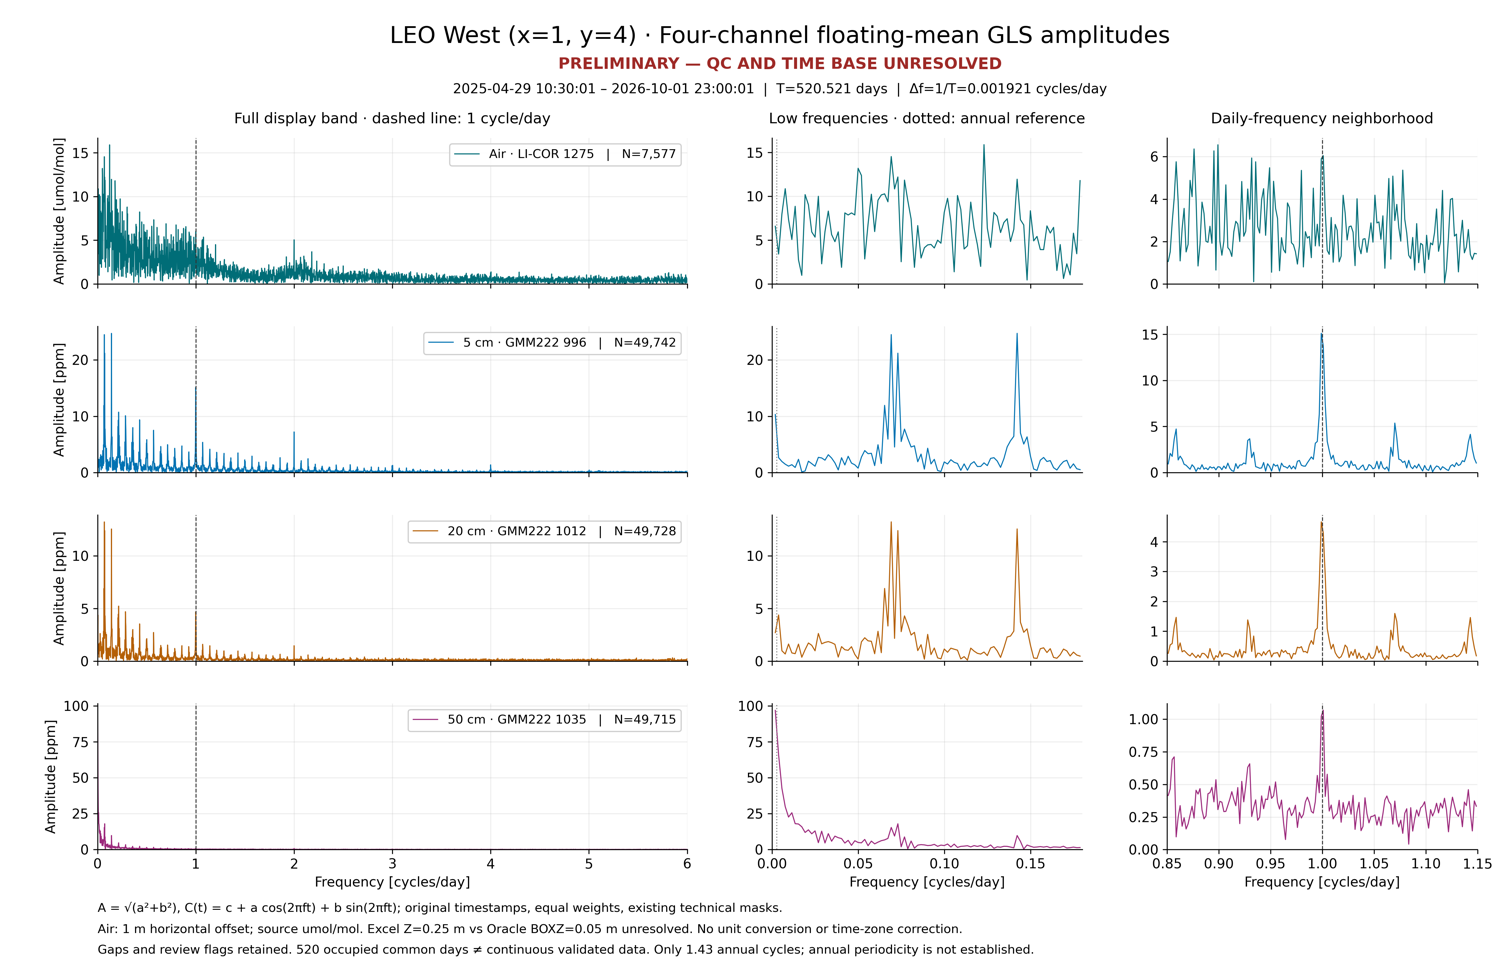

In [3]:
ps.plot_static(spectra, passport)
ps.write_html(series, spectra, passport)
def show_figure(name, width=1500):
    image = Image.open(ps.OUT / name)
    image.thumbnail((width, width))
    buffer = io.BytesIO(); image.save(buffer, format='PNG')
    display(DisplayImage(buffer.getvalue()))
show_figure('four_channel_spectra_17x11.png')

The print illustration has four channel rows, with a shared frequency axis in each column; each channel has its own amplitude scale and source units. The columns show the full band, low-frequency detail, and daily neighborhood. The low-frequency annual marker is a reference only.

[Vector PDF, 17 × 11 in](output/preliminary_spectra/four_channel_spectra_17x11.pdf) · [SVG](output/preliminary_spectra/four_channel_spectra_17x11.svg) · [PNG, 5100 × 3300 px, 300 dpi](output/preliminary_spectra/four_channel_spectra_17x11.png) · [Interactive static spectra](output/preliminary_spectra/interactive_spectra.html)

### Observed grid features, not approved frequencies

For 996 and 1012, interior local maxima include ≈0.06916 and ≈0.14217 cycles/day (about 14.46 and 7.03 days). A local maximum of 996 occurs at ≈0.998999 cycles/day; the closest grid point to exactly 1/day is ≈1.000921 cycles/day. Air has other low-frequency features, including ≈0.12295 cycles/day. Sensor 1035 has a large first-bin amplitude at 1/T, which must not be labeled an annual oscillation. The table ranks interior local maxima only; edge maxima are listed separately, not silently discarded. These features have not been separated from drift, sampling artifacts or unresolved sensor QC.

In [4]:
features = []
for s, sp in zip(series, spectra):
    a, f = sp['amplitude'], sp['f']
    interior = np.flatnonzero((a[1:-1] > a[:-2]) & (a[1:-1] >= a[2:])) + 1
    largest = interior[np.argsort(a[interior])[-3:][::-1]]
    for k in largest:
        features.append(dict(sensorid=s['sid'], kind='interior local maximum', cycles_per_day=f[k], period_days=1/f[k], amplitude=a[k], units=s['units']))
    for k in (0, len(a)-1):
        features.append(dict(sensorid=s['sid'], kind='band edge (not local peak claim)', cycles_per_day=f[k], period_days=1/f[k], amplitude=a[k], units=s['units']))
display(pd.DataFrame(features).round(6))

,sensorid,kind,cycles_per_day,period_days,amplitude,units
0,1275,interior local maximum,0.122954,8.133138,15.894794,umol/mol
1,1275,interior local maximum,0.069161,14.458912,14.538845,umol/mol
2,1275,interior local maximum,0.049950,20.020032,13.200668,umol/mol
3,1275,band edge (not local peak claim),0.001921,520.520833,6.587189,umol/mol
4,1275,band edge (not local peak claim),5.999760,0.166673,0.540760,umol/mol
5,996,interior local maximum,0.142165,7.034065,24.715077,ppm
6,996,interior local maximum,0.069161,14.458912,24.492350,ppm
7,996,interior local maximum,0.073004,13.697917,21.188358,ppm
8,996,band edge (not local peak claim),0.001921,520.520833,10.300550,ppm
9,996,band edge (not local peak claim),5.999760,0.166673,0.194882,ppm


### Actual sampling-window diagnostic

$$W(f)=\left|\frac{1}{N}\sum_i e^{2\pi\mathrm{i}ft_i}\right|^2,\qquad W(0)=1.$$

W is dimensionless and is drawn separately from physical amplitude. Its sidelobes describe possible replicas around a genuine frequency. They do not identify a measured peak as an artifact by themselves. The different air and basalt clocks have different windows; gaps remain in both. The displayed band does not exhaust aliases from frequencies outside it. Neither window inspection nor a passing numerical test provides scientific data admission.

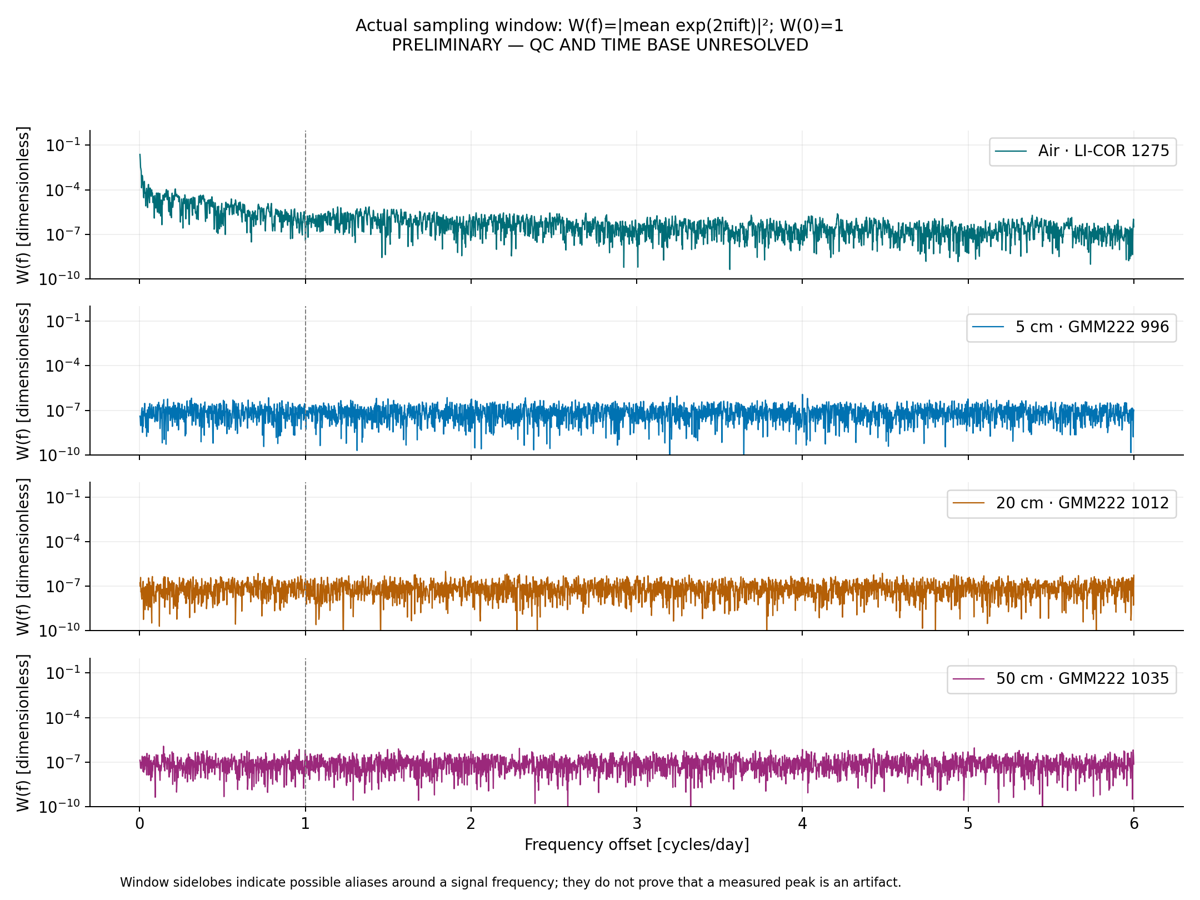

In [5]:
show_figure('sampling_window.png', 1200)

## Moving window: 30 days, step 1 day

The default is **492 real half-open windows**. Every spectrum is recomputed from that window's retained observations; no artificial zero spectrum fills missing data. The frequency grid is k/window_days below 6/day. A displayed frequency requires at least four distinct times, a nonsingular linear fit, and at least one cycle within actual observed span. Omitted frequencies or whole windows are labeled **INSUFFICIENT DATA** with the reason. These are numerical display conditions, **not new scientific quality thresholds**. Long gaps remain visible, without inventing an admissible maximum-gap threshold.

[Interactive parameterized windows](output/preliminary_spectra/sliding_spectra.html) are the main moving-window result: changing window_days and step_days rebuilds the dates, clears the cache, and recalculates real spectra on selection/play. All-channel, individual toggles, single-channel view and frequency zoom are available. Labels show counts, review flags, occupied days/2-hour bins, internal gaps and missing edges. Axes in the interactive explorer rescale to the selected frequency band; the GIF uses a fixed scale per channel across all frames.

[Default GIF](output/preliminary_spectra/sliding_spectra_30d_1d.gif) · [Per-window coverage](output/preliminary_spectra/sliding_30d_1d_coverage.csv). A short window cannot establish an annual period. The HTML bundles only the selected candidate-period values and retained review flags; full raw archives stay local.

In [6]:
starts, frequency, amplitudes, window_stats = ps.sliding(series, window_days=30, step_days=1)
ps.export_gif(starts, frequency, amplitudes, window_stats)
display(pd.DataFrame(window_stats).groupby('sensorid')[['n','days','max_gap_h']].agg(['min','max']))
print('Windows:', len(starts), '; frequency grid points:', len(frequency))

Sliding spectra: 1/492


Sliding spectra: 101/492


Sliding spectra: 201/492


Sliding spectra: 301/492


Sliding spectra: 401/492


n       days     max_gap_h           
           min   max  min max       min        max
sensorid                                          
996       2856  2875   30  30  0.500000   1.250278
1012      2857  2875   30  30  0.500278   1.250278
1035      2827  2874   30  30  0.500000   1.250278
1275       347   731   29  30  1.059167  43.334167

Windows: 492 ; frequency grid points: 179


## Historical 1035: material for discussion with I.G.

Before 29 April 2025, during the air era beginning 8 July 2023, the original 1035 source rows include **73,084 values above 3000 ppm out of 73,097 rows**, including duplicates/conflicts. All positive values are 6977.334–7033.895 ppm; median 7004.787 ppm, central 90% 6993.956–7015.572 ppm. Monthly medians across this long section range only 7002.811–7008.648 ppm. This describes a nearly constant high baseline, not a proven stuck sensor or established physical state. Neighboring 996/1012 monthly medians are approximately 512–561 and 247–285 ppm.

The following figure shows all original source rows, including service codes and conflicts, followed by a magnified positive-value view of 1035. Existing exclusions have not been changed. A diagnostic counterfactual restoring only 1035's `outside_0_3000` values above 3000, while keeping other existing exclusions, increases common occupied days from **520 to 773 (+253)**. Restored values did not pass the downstream QC that the old range mask prevented; 773 is a coverage upper scenario, not admitted data.

**Question for I. R. Gabitov:** Does the persistent near-7005 ppm level reflect instrument saturation / calibration / scaling, or can it represent concentration? Which independent instrument records and agreed validation would be required before reviewing the 3000 ppm upper rule for this channel? No new threshold or correction is selected here.

[Detailed existing section](details/02_data_checks.md#1035-period-extension-discussion) · [Monthly descriptive ranges](output/preliminary_spectra/historical_monthly_ranges.csv).

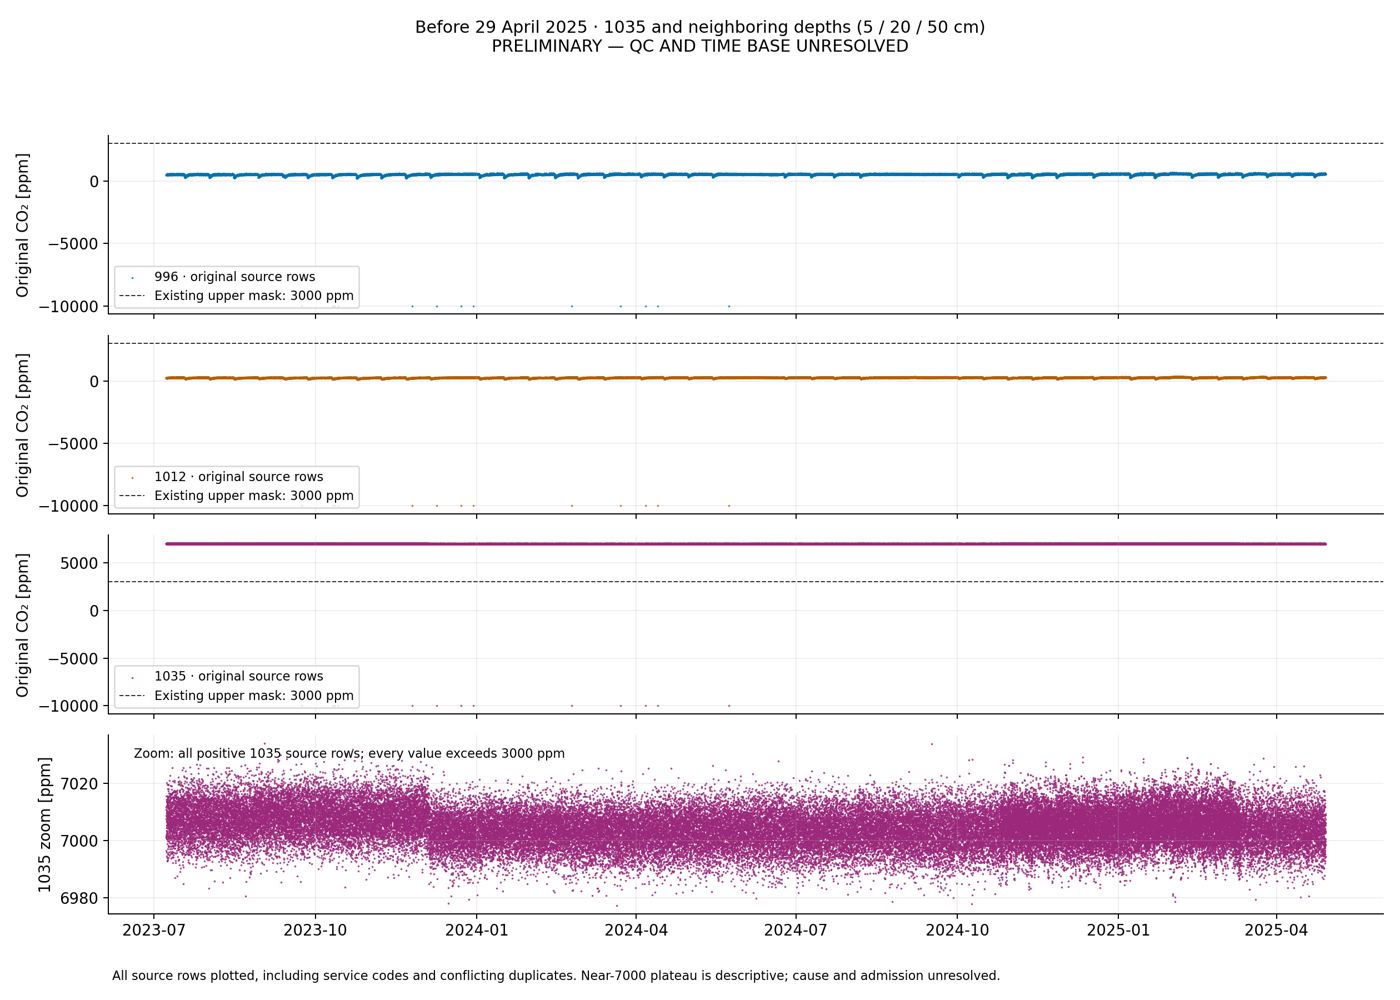

,scenario,common_days,first,last
0,existing masks,520,2025-04-29,2026-10-01
1,restore only >3000 at 1035; unreviewed counter...,773,2023-07-08,2026-10-01


In [7]:
historical = ps.historical_diagnostic(work, raw)
show_figure('1035_before_candidate.png', 1400)
display(pd.DataFrame(historical['scenarios']))

## Validation, reproducibility and limits

The numerical tests check known amplitudes/frequencies, shifted timestamps, artificial gaps, an independent least-squares solver, absence/singular cases, changed window grids, and the JavaScript worker against Python. Run from the repository root:

```bash
python3 -m unittest discover -s Project_description/sensorDB/tests -p test_preliminary_spectra.py -v
python3 Project_description/sensorDB/preliminary_spectra.py
```

This notebook also regenerates the passport, spectra, print exports, both HTML files, historical diagnostics and the default GIF when executed from a clean kernel. Python dependencies: numpy, pandas, pyarrow, matplotlib, Pillow; notebook execution additionally needs IPython / ipykernel / nbclient / nbformat. No Oracle connection is used. The original full archive and its diagnostic copies must be present at the pinned path. Input checksums are verified before and after calculations; failures stop execution. [Passport/checksums](output/preliminary_spectra/passport.json).

The PDF was rasterized for visual inspection and its physical dimensions checked. HTML's numerical worker is cross-checked independently; automated visual browser inspection was blocked by the local-file URL policy and is not claimed.

**Outcome:** reproducible preliminary amplitude illustrations and moving-window demonstration for the chosen quartet. **Still unresolved:** LI-COR numeric QC; subsurface review flags; source clock/time-zone alignment; air height mapping; scientific validation and interpretation of frequencies; admission of the pre-29-April-2025 1035 history. No phase calculation, final frequency selection, new cleaning threshold, final completion of stage 0.2, or main chapter 1.

[Back to the existing preparation section](details/02_data_checks.md#preliminary-four-channel-spectra) · [Research plan](PLAN.md)

In [8]:
for path, checksum in passport['hashes'].items():
    assert ps.digest(ROOT / path) == checksum, f'Source changed: {path}'
assert passport['common_days'] == 520
print('Input checksums unchanged. Preliminary demonstration complete; scientific admission remains unresolved.')

Input checksums unchanged. Preliminary demonstration complete; scientific admission remains unresolved.
